# EEG-Based Epileptic Seizure Prediction Using Machine Learning

## Comparative Analysis of Preprocessing Pipelines, Regularization Techniques, and Class Imbalance Handling

### Major Assignment — Data Mining

**Student Name:** Usman Ahmad    
**Submitted To:** Dr. Adnan Amin  
**Tools:** Python, Jupyter Notebook, VS Code  
**Environment:** Local Python Virtual Environment

# Introduction

Epileptic seizure prediction is an important research area in biomedical signal processing and healthcare machine learning. EEG signals contain neurological activity information that can help identify abnormal brain activity associated with epileptic seizures.

In this project, I aim to investigate the impact of preprocessing pipelines, regularization techniques, and class imbalance handling methods on seizure prediction performance using machine learning approaches.

The project mainly focuses on Logistic Regression as a baseline classifier while analyzing:
- overfitting and underfitting behavior,
- feature sparsity,
- preprocessing order impact,
- and model generalization across multiple EEG datasets.

Multiple publicly available EEG datasets are used to evaluate the stability and effectiveness of different preprocessing and modeling approaches.

# Project Objectives

The main objectives of this project are:

- To develop a machine learning pipeline for EEG seizure prediction
- To compare multiple preprocessing pipelines
- To evaluate Logistic Regression as a baseline classifier
- To analyze overfitting and underfitting behavior
- To compare L1, L2, and Elastic Net regularization methods
- To investigate class imbalance handling techniques
- To evaluate generalization performance across multiple EEG datasets
- To generate research-quality visualizations and comparative analysis

# Selected Datasets

The following datasets are used in this project:

| Dataset | Purpose |
|---|---|
| epilepsy_federated_dataset.csv | EEG seizure classification |
| Epileptic Seizure Recognition.csv | Benchmark seizure prediction |
| seizure_events.csv | Seizure event analysis |
| seizure_256Hz_dataset | EEG extracted feature dataset |

These datasets provide different EEG signal characteristics and seizure distributions, which helps evaluate preprocessing stability and model generalization performance.

# Dataset Loading and Environment Verification

In this step, I verified that the Python environment and required libraries are working correctly. 

I also loaded the available EEG datasets into Python to inspect their structure, dimensions, and overall accessibility before starting preprocessing and machine learning experiments.

The `data/raw` folder stores original untouched datasets.

This is important because:
- original data remains 
- preprocessing experiments become reproducible
- processed datasets can later be stored separately
- research workflow remains organized

# Dataset Loading and Initial Exploration

In this step, I loaded the EEG datasets and performed an initial exploration to understand their structure, dimensions, feature columns, and class distributions.

This analysis helps identify preprocessing requirements and prepares the datasets for machine learning experiments.

In [5]:
# ============================================================
# Step 6 — Import Required Libraries
# Purpose:
# Import libraries for dataset loading and analysis
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# Step 6 — Define Dataset Paths
# Purpose:
# Define file paths for EEG datasets
# ============================================================

# Main project path
project_path = Path(
    r"D:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project"
)

# Raw data folder
raw_data_path = project_path / "data" / "raw"

# Dataset paths
federated_dataset_path = raw_data_path / "epilepsy_federated_dataset.csv"

seizure_recognition_path = (
    raw_data_path / "Epileptic Seizure Recognition.csv"
)

seizure_events_path = raw_data_path / "seizure_events.csv"

print("Dataset paths created successfully.")

Dataset paths created successfully.


In [7]:
# ============================================================
# Step 6 — Load EEG Datasets
# Purpose:
# Load datasets into pandas DataFrames
# ============================================================

# Load datasets
federated_df = pd.read_csv(federated_dataset_path)

seizure_recognition_df = pd.read_csv(seizure_recognition_path)

seizure_events_df = pd.read_csv(seizure_events_path)

print("Datasets loaded successfully.\n")

# Display dataset shapes
print("Federated Dataset Shape:")
print(federated_df.shape)

print("\nSeizure Recognition Dataset Shape:")
print(seizure_recognition_df.shape)

print("\nSeizure Events Dataset Shape:")
print(seizure_events_df.shape)

Datasets loaded successfully.

Federated Dataset Shape:
(289010, 52)

Seizure Recognition Dataset Shape:
(11500, 180)

Seizure Events Dataset Shape:
(198, 3)


In [8]:
# ============================================================
# Step 6 — Preview Datasets
# Purpose:
# Display first few rows of datasets
# ============================================================

print("Federated Dataset Preview")
display(federated_df.head())

print("\nSeizure Recognition Dataset Preview")
display(seizure_recognition_df.head())

print("\nSeizure Events Dataset Preview")
display(seizure_events_df.head())

Federated Dataset Preview


,Mean_EEG_Amplitude,EEG_Std_Dev,EEG_Skewness,EEG_Kurtosis,Zero_Crossing_Rate,Root_Mean_Square,Peak_to_Peak_Amplitude,Signal_Energy,Variance_of_EEG_Signals,Interquartile_Range,Auto_Correlation_of_EEG_Signals,Cross_Correlation_Between_Channels,Hjorth_Mobility,Hjorth_Complexity,Line_Length_Feature,Delta_Band_Power,Theta_Band_Power,Alpha_Band_Power,Beta_Band_Power,Gamma_Band_Power,Low_to_High_Frequency_Power_Ratio,Power_Spectral_Density,Spectral_Edge_Frequency,Spectral_Entropy,Fourier_Transform_Features,Wavelet_Entropy,Wavelet_Energy,Discrete_Wavelet_Transform,Continuous_Wavelet_Transform,Wavelet_Based_Shannon_Entropy,Sample_Entropy,Approximate_Entropy,Shannon_Entropy,Permutation_Entropy,Lyapunov_Exponent,Hurst_Exponent,Detrended_Fluctuation_Analysis,Higuchi_Fractal_Dimension,Katz_Fractal_Dimension,Lempel_Ziv_Complexity,Seizure_Duration,Pre_Seizure_Pattern,Post_Seizure_Recovery,Seizure_Frequency_Per_Hour,Interictal_Spike_Rate,Seizure_Intensity_Index,Age,Gender,Medication_Status,Seizure_History,Multi_Class_Label,Seizure_Type_Label
0,0.463995,1.560095,-1.953752,1.417816,53.428102,2.552078,3.734923,17.276018,4.627323,2.054438,0.230933,0.136317,0.710989,2.183192,1.004372,1.207438,0.567625,0.524007,-0.161284,-0.039924,1.741657,0.332283,77.759558,4.427274,7.306757,2.293538,12.237743,2.833461,10.338299,4.087257,0.669797,0.602838,1.925348,0.501950,0.248701,-0.237029,0.084268,1.459174,0.459652,0.372334,1.424513,0.298005,0.382942,3.250527,6.405068,0.686015,87,0,1,18,0,2
1,0.324632,0.953233,-0.034527,1.333842,61.486037,1.968715,1.285857,8.099144,3.572132,0.541116,0.063214,0.079108,0.923336,0.446129,2.159020,0.241474,0.404474,0.074329,-0.111100,-0.037773,0.061087,0.179559,102.998174,3.222652,7.470282,4.381704,5.948213,3.344317,7.926818,3.318318,1.217503,0.478108,1.455698,0.165673,0.224135,-0.253597,2.091604,0.688578,0.177741,0.683109,15.641924,0.232762,0.423757,9.210367,3.192447,0.944232,1,1,0,0,2,0
2,0.499497,0.419182,-0.697510,7.345670,33.569696,2.226112,1.869052,7.211445,4.022814,0.939826,0.043537,0.075677,0.397337,1.902939,0.201200,0.463070,0.194077,0.122737,-0.046285,-0.024686,4.851740,0.653697,84.668546,3.351570,6.219103,2.762652,9.131829,5.839558,3.146635,2.282921,1.053150,0.926617,1.829170,0.152374,0.205119,-0.562112,1.638041,0.970989,0.780171,1.628583,0.562129,0.456977,0.407296,3.212498,4.143878,0.288099,53,1,1,7,0,1
3,0.721730,0.962900,-1.161993,0.774990,81.811036,2.349506,3.524583,13.940857,2.152732,1.032526,0.163113,0.122203,0.492076,0.840896,0.832678,0.831719,0.143506,0.024136,-0.055812,-0.052281,6.874577,0.322266,5.286621,2.434615,2.580545,2.302283,12.123970,2.512876,9.019375,1.270328,1.296942,1.123526,0.672597,0.650423,0.131535,-0.075294,0.819848,0.813145,0.959261,1.369905,1.422229,0.220526,0.184500,1.310543,7.854328,1.463863,18,0,0,18,0,2
4,0.305064,1.253647,-1.166630,1.265767,38.618300,1.994878,2.902625,7.698449,4.332478,0.660386,0.156901,0.155604,1.054887,1.189594,1.781949,1.396656,0.494980,0.243004,-0.073291,-0.015447,4.089783,0.327775,86.937180,3.083250,4.888853,3.496721,2.341484,3.611934,6.272549,3.133159,0.855940,0.032101,0.513832,0.307572,0.155513,-0.172345,1.779324,0.317994,0.624070,0.684325,8.675854,0.174483,0.368572,6.087262,1.659506,0.121632,12,1,1,3,1,1



Seizure Recognition Dataset Preview


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64,X65,X66,X67,X68,X69,X70,X71,X72,X73,X74,X75,X76,X77,X78,X79,X80,X81,X82,X83,X84,X85,X86,X87,X88,X89,X90,X91,X92,X93,X94,X95,X96,X97,X98,X99,X100,X101,X102,X103,X104,X105,X106,X107,X108,X109,X110,X111,X112,X113,X114,X115,X116,X117,X118,X119,X120,X121,X122,X123,X124,X125,X126,X127,X128,X129,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,46,13,-19,-61,-96,-130,-132,-116,-115,-71,-14,25,19,6,9,21,13,-37,-58,-33,5,47,80,101,88,73,69,41,-13,-31,-61,-80,-77,-66,-43,5,87,129,121,88,12,-76,-150,-207,-186,-165,-148,-103,-33,40,94,75,8,-81,-155,-227,-262,-233,-218,-187,-126,-65,-12,27,61,49,9,-46,-124,-210,-281,-265,-181,-89,-4,53,53,38,43,31,34,9,-7,-34,-70,-84,-101,-70,-11,42,62,66,74,64,59,56,36,-11,-30,-43,-23,8,42,77,103,135,121,79,59,43,54,90,111,107,64,32,18,-25,-69,-65,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,447,397,339,312,314,326,335,332,324,310,312,309,309,303,297,295,295,293,286,279,283,301,308,285,252,215,194,169,111,-74,-388,-679,-892,-949,-972,-1001,-1006,-949,-847,-668,-432,-153,72,226,326,392,461,495,513,511,496,479,453,440,427,414,399,385,385,404,432,444,437,418,392,373,363,365,372,385,388,383,371,360,353,334,303,252,200,153,151,143,48,-206,-548,-859,-1067,-1069,-957,-780,-597,-460,-357,-276,-224,-210,-350,-930,-1413,-1716,-1360,-662,-96,243,323,241,29,-167,-228,-136,27,146,229,269,297,307,303,305,306,307,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,-40,-35,-39,-32,-13,7,34,41,33,6,-15,-30,-47,-53,-65,-64,-68,-85,-98,-109,-82,-57,-38,-40,-36,-31,-13,11,19,9,-20,-48,-71,-71,-57,-32,-13,6,29,27,25,10,-7,-36,-47,-37,-36,-22,-32,-38,-55,-61,-64,-72,-67,-53,-25,-10,-4,-23,-55,-93,-102,-106,-101,-69,-45,-42,-57,-64,-77,-80,-77,-78,-56,-34,-5,10,5,-5,-44,-75,-99,-110,-104,-103,-94,-105,-108,-110,-99,-89,-82,-76,-80,-90,-106,-106,-108,-87,-60,-37,-26,-15,-6,-14,-23,-34,-41,-54,-82,-107,-126,-124,-108,-84,-68,-61,-56,-63,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,-68,-76,-76,-72,-67,-69,-69,-69,-67,-68,-69,-67,-66,-58,-54,-56,-70,-80,-82,-85,-74,-70,-71,-82,-88,-93,-97,-89,-87,-83,-70,-50,-37,-31,-32,-39,-54,-64,-68,-67,-69,-63,-60,-63,-55,-43,-37,-27,-31,-35,-47,-58,-63,-74,-73,-67,-60,-56,-49,-46,-57,-58,-62,-63,-63,-61,-56,-65,-62,-57,-61,-63,-66,-69,-86,-89,-86,-83,-87,-80,-69,-62,-57,-60,-60,-68,-58,-53,-57,-66,-66,-73,-78,-73,-84,-92,-97,-88,-81,-72,-61,-66,-72,-88,-90,-88,-77,-58,-53,-61,-69,-66,-74,-69,-61,-51,-45,-45,-49,-58,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,-68,-78,-75,-55,-41,-19,-20,-29,-36,-20,1,16,14,-14,-42,-56,-45,-45,-45,-38,-47,-45,-37,-3,23,39,27,0,-28,-44,-37,-22,5,30,31,6,-32,-27,-27,2,13,-6,-29,-41,-22,-13,-16,-31,-52,-60,-40,-16,0,14,24,36,39,3


Seizure Events Dataset Preview


,series_id,onset,offset
0,chb01_03.edf,2996,3036
1,chb01_04.edf,1467,1494
2,chb01_15.edf,1732,1772
3,chb01_16.edf,1015,1066
4,chb01_18.edf,1720,1810


# Initial Exploratory Data Analysis (EDA)

In this step, I performed an initial exploratory analysis on the EEG datasets to understand their structure, feature composition, missing values, and target distributions.

This analysis helps identify preprocessing requirements and potential challenges such as class imbalance and noisy features before model development.

In [9]:
# ============================================================
# Step 7 — Dataset Information
# Purpose:
# Display dataset structure and feature information
# ============================================================

print("=" * 60)
print("Federated Dataset Information")
print("=" * 60)

display(federated_df.info())

print("\n")

print("=" * 60)
print("Seizure Recognition Dataset Information")
print("=" * 60)

display(seizure_recognition_df.info())

print("\n")

print("=" * 60)
print("Seizure Events Dataset Information")
print("=" * 60)

display(seizure_events_df.info())

Federated Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 289010 entries, 0 to 289009
Data columns (total 52 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Mean_EEG_Amplitude                  289010 non-null  float64
 1   EEG_Std_Dev                         289010 non-null  float64
 2   EEG_Skewness                        289010 non-null  float64
 3   EEG_Kurtosis                        289010 non-null  float64
 4   Zero_Crossing_Rate                  289010 non-null  float64
 5   Root_Mean_Square                    289010 non-null  float64
 6   Peak_to_Peak_Amplitude              289010 non-null  float64
 7   Signal_Energy                       289010 non-null  float64
 8   Variance_of_EEG_Signals             289010 non-null  float64
 9   Interquartile_Range                 289010 non-null  float64
 10  Auto_Correlation_of_EEG_Signals     289010 non-null  float64
 11  Cross_C

None



Seizure Recognition Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), str(1)
memory usage: 15.8 MB


None



Seizure Events Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   series_id  198 non-null    str  
 1   onset      198 non-null    int64
 2   offset     198 non-null    int64
dtypes: int64(2), str(1)
memory usage: 4.8 KB


None

In [10]:
# ============================================================
# Step 7 — Missing Value Analysis
# Purpose:
# Check missing values in all datasets
# ============================================================

print("=" * 60)
print("Missing Values — Federated Dataset")
print("=" * 60)

display(federated_df.isnull().sum())

print("\n")

print("=" * 60)
print("Missing Values — Seizure Recognition Dataset")
print("=" * 60)

display(seizure_recognition_df.isnull().sum())

print("\n")

print("=" * 60)
print("Missing Values — Seizure Events Dataset")
print("=" * 60)

display(seizure_events_df.isnull().sum())

Missing Values — Federated Dataset


Mean_EEG_Amplitude                    0
EEG_Std_Dev                           0
EEG_Skewness                          0
EEG_Kurtosis                          0
Zero_Crossing_Rate                    0
Root_Mean_Square                      0
Peak_to_Peak_Amplitude                0
Signal_Energy                         0
Variance_of_EEG_Signals               0
Interquartile_Range                   0
Auto_Correlation_of_EEG_Signals       0
Cross_Correlation_Between_Channels    0
Hjorth_Mobility                       0
Hjorth_Complexity                     0
Line_Length_Feature                   0
Delta_Band_Power                      0
Theta_Band_Power                      0
Alpha_Band_Power                      0
Beta_Band_Power                       0
Gamma_Band_Power                      0
Low_to_High_Frequency_Power_Ratio     0
Power_Spectral_Density                0
Spectral_Edge_Frequency               0
Spectral_Entropy                      0
Fourier_Transform_Features            0




Missing Values — Seizure Recognition Dataset


Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64



Missing Values — Seizure Events Dataset


series_id    0
onset        0
offset       0
dtype: int64

In [11]:
# ============================================================
# Step 7 — Duplicate Record Analysis
# Purpose:
# Identify duplicate rows in datasets
# ============================================================

print("=" * 60)
print("Duplicate Records Analysis")
print("=" * 60)

print(f"Federated Dataset Duplicates: {federated_df.duplicated().sum()}")

print(f"Seizure Recognition Dataset Duplicates: "
      f"{seizure_recognition_df.duplicated().sum()}")

print(f"Seizure Events Dataset Duplicates: "
      f"{seizure_events_df.duplicated().sum()}")

Duplicate Records Analysis
Federated Dataset Duplicates: 0
Seizure Recognition Dataset Duplicates: 0
Seizure Events Dataset Duplicates: 0


============================================================
Duplicate Records Analysis
============================================================
Federated Dataset Duplicates: 0
Seizure Recognition Dataset Duplicates: 0
Seizure Events Dataset Duplicates: 0

In [13]:
# ============================================================
# Step 8 — Import Visualization Libraries
# Purpose:
# Import libraries for dataset visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")

print("Visualization libraries loaded successfully.")

Visualization libraries loaded successfully.


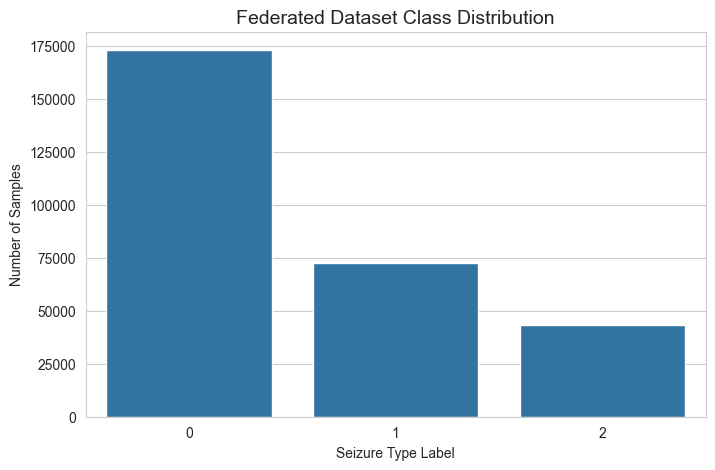

In [14]:
# ============================================================
# Step 8 — Federated Dataset Class Distribution
# Purpose:
# Visualize seizure class distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=federated_df["Seizure_Type_Label"]
)

plt.title(
    "Federated Dataset Class Distribution",
    fontsize=14
)

plt.xlabel("Seizure Type Label")
plt.ylabel("Number of Samples")

plt.show()

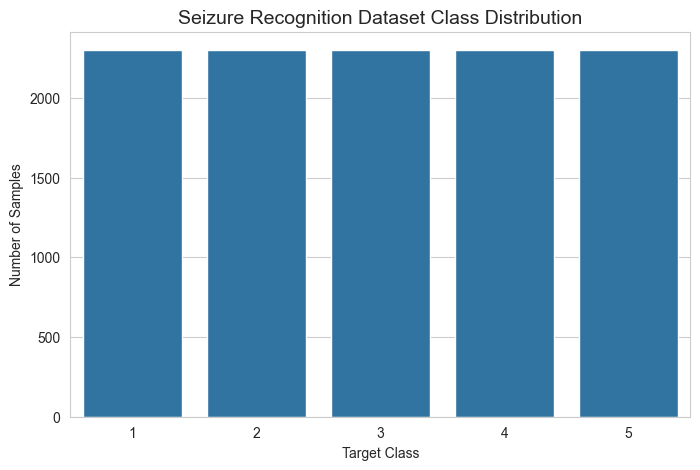

In [15]:
# ============================================================
# Step 8 — Seizure Recognition Dataset Distribution
# Purpose:
# Visualize seizure recognition target distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=seizure_recognition_df["y"]
)

plt.title(
    "Seizure Recognition Dataset Class Distribution",
    fontsize=14
)

plt.xlabel("Target Class")
plt.ylabel("Number of Samples")

plt.show()

The Federated EEG dataset shows noticeable class imbalance, where class `0` contains significantly more samples than classes `1` and `2`.

In contrast, the Seizure Recognition dataset appears balanced across all target classes.

This observation justifies the later use of imbalance handling techniques such as SMOTE and class weighting during machine learning experiments.

# Dataset Cleaning and Preparation

In this step, I prepared the EEG datasets for machine learning experiments by separating input features and target labels.

Unnecessary identifier columns were removed to avoid introducing irrelevant information into the learning process.

In [16]:
# ============================================================
# Step 9 — Prepare Federated Dataset
# Purpose:
# Separate features and target labels
# ============================================================

# Features
X_federated = federated_df.drop(
    columns=["Seizure_Type_Label"]
)

# Target
y_federated = federated_df["Seizure_Type_Label"]

print("Federated Dataset Prepared Successfully.\n")

print("Feature Matrix Shape:")
print(X_federated.shape)

print("\nTarget Vector Shape:")
print(y_federated.shape)

Federated Dataset Prepared Successfully.

Feature Matrix Shape:
(289010, 51)

Target Vector Shape:
(289010,)


In [17]:
# ============================================================
# Step 9 — Prepare Seizure Recognition Dataset
# Purpose:
# Remove unnecessary identifier column
# and separate features and target
# ============================================================

# Remove identifier column
seizure_recognition_df = seizure_recognition_df.drop(
    columns=["Unnamed"]
)

# Features
X_recognition = seizure_recognition_df.drop(
    columns=["y"]
)

# Target
y_recognition = seizure_recognition_df["y"]

print("Seizure Recognition Dataset Prepared Successfully.\n")

print("Feature Matrix Shape:")
print(X_recognition.shape)

print("\nTarget Vector Shape:")
print(y_recognition.shape)

Seizure Recognition Dataset Prepared Successfully.

Feature Matrix Shape:
(11500, 178)

Target Vector Shape:
(11500,)


In [18]:
# ============================================================
# Step 9 — Verify Target Classes
# Purpose:
# Check unique target labels
# ============================================================

print("Federated Dataset Classes:")
print(sorted(y_federated.unique()))

print("\n")

print("Seizure Recognition Dataset Classes:")
print(sorted(y_recognition.unique()))

Federated Dataset Classes:
[np.int64(0), np.int64(1), np.int64(2)]


Seizure Recognition Dataset Classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Machine learning models require:
- clean feature matrices,
- properly separated target labels,
- and removal of irrelevant identifier columns.

This preparation step ensures that later preprocessing pipelines and classification experiments are performed correctly.

# EEG Preprocessing Pipeline — Standardization

In this step, I developed the first preprocessing pipeline for EEG seizure prediction experiments.

The pipeline includes:
- train-test splitting,
- feature standardization,
- and preparation of normalized input features for machine learning models.

Feature scaling is important because EEG features exist on different numerical ranges, and many machine learning algorithms perform better when features are standardized.

In [19]:
# ============================================================
# Step 10 — Import Preprocessing Libraries
# Purpose:
# Import libraries for preprocessing
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [20]:
# ============================================================
# Step 10 — Train-Test Split
# Purpose:
# Split federated dataset into training and testing sets
# ============================================================

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    
    X_federated,
    y_federated,
    
    test_size=0.2,
    
    random_state=42,
    
    stratify=y_federated
)

print("Federated Dataset Split Successfully.\n")

print(f"Training Features Shape: {Xf_train.shape}")
print(f"Testing Features Shape: {Xf_test.shape}")

print("\n")

print(f"Training Labels Shape: {yf_train.shape}")
print(f"Testing Labels Shape: {yf_test.shape}")

Federated Dataset Split Successfully.

Training Features Shape: (231208, 51)
Testing Features Shape: (57802, 51)


Training Labels Shape: (231208,)
Testing Labels Shape: (57802,)


In [21]:
# ============================================================
# Step 10 — Feature Standardization
# Purpose:
# Normalize EEG feature values
# ============================================================

# Create scaler
scaler_federated = StandardScaler()

# Fit scaler on training data
Xf_train_scaled = scaler_federated.fit_transform(
    Xf_train
)

# Transform testing data
Xf_test_scaled = scaler_federated.transform(
    Xf_test
)

print("Feature standardization completed successfully.\n")

print("Scaled Training Shape:")
print(Xf_train_scaled.shape)

print("\nScaled Testing Shape:")
print(Xf_test_scaled.shape)

Feature standardization completed successfully.

Scaled Training Shape:
(231208, 51)

Scaled Testing Shape:
(57802, 51)


Standardization transforms features to a common scale with:
- mean ≈ 0
- standard deviation ≈ 1

This improves:
- Logistic Regression stability,
- convergence speed,
- and regularization performance.

It is especially important for EEG features because signal-derived attributes often have very different numerical ranges.

# Logistic Regression Baseline Model

In this step, I trained the first baseline Logistic Regression model using standardized EEG features from the Federated dataset.

The purpose of this baseline model is to establish an initial reference point before applying advanced preprocessing pipelines, regularization techniques, and imbalance handling methods.

In [22]:
# ============================================================
# Step 11 — Import Machine Learning Libraries
# Purpose:
# Import Logistic Regression and evaluation metrics
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


In [23]:
# ============================================================
# Step 11 — Train Logistic Regression Model
# Purpose:
# Train baseline Logistic Regression classifier
# ============================================================

# Create Logistic Regression model
logistic_model = LogisticRegression(
    
    max_iter=1000,
    
    random_state=42
)

# Train model
logistic_model.fit(
    Xf_train_scaled,
    yf_train
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [24]:
# ============================================================
# Step 11 — Generate Predictions
# Purpose:
# Predict seizure classes on testing data
# ============================================================

# Generate predictions
yf_pred = logistic_model.predict(
    Xf_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [25]:
# ============================================================
# Step 11 — Evaluate Logistic Regression
# Purpose:
# Evaluate baseline model performance
# ============================================================

# Calculate accuracy
baseline_accuracy = accuracy_score(
    yf_test,
    yf_pred
)

print("=" * 60)
print("Baseline Logistic Regression Accuracy")
print("=" * 60)

print(f"Accuracy: {baseline_accuracy:.4f}")

print("\n")

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        yf_test,
        yf_pred
    )
)

Baseline Logistic Regression Accuracy
Accuracy: 0.5987


Classification Report
              precision    recall  f1-score   support

           0       0.60      1.00      0.75     34607
           1       0.00      0.00      0.00     14495
           2       0.00      0.00      0.00      8700

    accuracy                           0.60     57802
   macro avg       0.20      0.33      0.25     57802
weighted avg       0.36      0.60      0.45     57802



d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-de

The baseline Logistic Regression model achieved approximately 60% accuracy, but the classification report shows that the model predicted only the majority class (`0`) while completely ignoring minority classes (`1` and `2`).

This indicates severe class imbalance and poor minority class generalization.

Although the accuracy appears moderate, the model is not practically effective for seizure prediction because it fails to detect important seizure classes.

The Federated EEG dataset is highly imbalanced:

- Class `0` contains most samples
- Classes `1` and `2` contain significantly fewer samples

As a result, the Logistic Regression model became biased toward the majority class during training.

This behavior is common in healthcare machine learning problems where abnormal events occur less frequently than normal patterns.

The warning:

`UndefinedMetricWarning`

appears because the model never predicted classes `1` and `2`.

Therefore:
- precision becomes undefined,
- recall becomes zero,
- and F1-score also becomes zero for minority classes.

# Baseline Model Interpretation

The baseline Logistic Regression model showed strong bias toward the majority seizure class due to dataset imbalance.

Although the overall accuracy was approximately 60%, the model completely failed to classify minority seizure classes.

This result demonstrates that accuracy alone is not sufficient for evaluating seizure prediction models, especially in imbalanced healthcare datasets.

The observed behavior also highlights the importance of:
- imbalance handling techniques,
- regularization methods,
- and preprocessing strategies

for improving minority class detection and overall model generalization.

In [26]:
# ============================================================
# Step 12 — Class Percentage Analysis
# Purpose:
# Analyze class imbalance percentages
# ============================================================

# Calculate percentage distribution
class_percentages = (
    y_federated.value_counts(normalize=True) * 100
)

print("=" * 60)
print("Federated Dataset Class Distribution (%)")
print("=" * 60)

print(class_percentages)

Federated Dataset Class Distribution (%)
Seizure_Type_Label
0    59.871631
1    25.076641
2    15.051728
Name: proportion, dtype: float64


The baseline Logistic Regression model demonstrated strong majority-class bias caused by severe dataset imbalance.

Although the model achieved moderate accuracy, it failed to correctly identify minority seizure classes, resulting in poor generalization performance.

This experiment highlights the limitation of accuracy as a standalone evaluation metric for imbalanced medical datasets.

The obtained results justify the application of imbalance handling methods such as SMOTE in subsequent experiments.

# SMOTE-Based Class Imbalance Handling

In this step, I applied SMOTE (Synthetic Minority Oversampling Technique) to address the severe class imbalance problem observed in the Federated EEG dataset.

SMOTE generates synthetic samples for minority classes, which helps machine learning models learn balanced decision boundaries and improves seizure class prediction performance.

In [27]:
# ============================================================
# Step 13 — Import SMOTE
# Purpose:
# Import imbalance handling technique
# ============================================================

from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [28]:
# ============================================================
# Step 13 — Apply SMOTE
# Purpose:
# Balance EEG seizure classes
# ============================================================

# Create SMOTE object
smote = SMOTE(
    
    random_state=42
)

# Apply SMOTE on training data only
Xf_train_smote, yf_train_smote = smote.fit_resample(
    
    Xf_train_scaled,
    yf_train
)

print("SMOTE applied successfully.\n")

print("Original Training Shape:")
print(Xf_train_scaled.shape)

print("\nBalanced Training Shape:")
print(Xf_train_smote.shape)

SMOTE applied successfully.

Original Training Shape:
(231208, 51)

Balanced Training Shape:
(415284, 51)


In [29]:
# ============================================================
# Step 13 — Verify Balanced Classes
# Purpose:
# Check class distribution after SMOTE
# ============================================================

print("=" * 60)
print("Balanced Class Distribution")
print("=" * 60)

print(
    pd.Series(yf_train_smote).value_counts()
)

Balanced Class Distribution
Seizure_Type_Label
0    138428
2    138428
1    138428
Name: count, dtype: int64


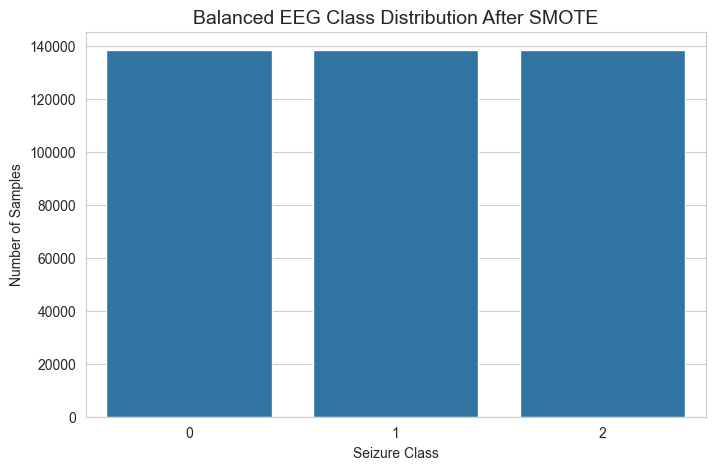

In [30]:
# ============================================================
# Step 13 — Visualize Balanced Dataset
# Purpose:
# Plot balanced class distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=yf_train_smote
)

plt.title(
    "Balanced EEG Class Distribution After SMOTE",
    fontsize=14
)

plt.xlabel("Seizure Class")
plt.ylabel("Number of Samples")

plt.show()

SMOTE helps reduce majority-class bias by generating synthetic minority-class samples instead of simply duplicating existing records.

This improves:
- minority class learning,
- seizure detection capability,
- recall performance,
- and overall model generalization.

# SMOTE Result Interpretation

After applying SMOTE, the EEG dataset became balanced across all seizure classes.

This balancing process reduces majority-class bias and allows the machine learning model to learn seizure-related patterns more effectively.

The balanced dataset is expected to improve:
- recall for minority seizure classes,
- overall classification stability,
- and generalization performance.

# Logistic Regression After SMOTE

In this step, I retrained the Logistic Regression model using the balanced EEG dataset generated through SMOTE.

The objective of this experiment is to evaluate whether class balancing improves seizure class prediction performance, especially for minority classes.

In [31]:
# ============================================================
# Step 14 — Train Logistic Regression After SMOTE
# Purpose:
# Train model on balanced EEG dataset
# ============================================================

# Create Logistic Regression model
logistic_model_smote = LogisticRegression(
    
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model_smote.fit(
    
    Xf_train_smote,
    yf_train_smote
)

print("Logistic Regression trained successfully on SMOTE dataset.")

Logistic Regression trained successfully on SMOTE dataset.


In [32]:
# ============================================================
# Step 14 — Prediction After SMOTE
# Purpose:
# Predict seizure classes using trained model
# ============================================================

# Predict on testing data
yf_pred_smote = logistic_model_smote.predict(
    
    Xf_test_scaled
)

print("Predictions completed successfully.")

Predictions completed successfully.


In [33]:
# ============================================================
# Step 14 — Evaluate SMOTE Model
# Purpose:
# Calculate performance metrics
# ============================================================

# Calculate accuracy
smote_accuracy = accuracy_score(
    
    yf_test,
    yf_pred_smote
)

print("=" * 60)
print("Logistic Regression Accuracy After SMOTE")
print("=" * 60)

print(f"Accuracy: {smote_accuracy:.4f}")

print("\n")

print("=" * 60)
print("Classification Report After SMOTE")
print("=" * 60)

print(
    classification_report(
        
        yf_test,
        yf_pred_smote
    )
)

Logistic Regression Accuracy After SMOTE
Accuracy: 0.3693


Classification Report After SMOTE
              precision    recall  f1-score   support

           0       0.60      0.45      0.51     34607
           1       0.25      0.18      0.21     14495
           2       0.15      0.36      0.21      8700

    accuracy                           0.37     57802
   macro avg       0.33      0.33      0.31     57802
weighted avg       0.44      0.37      0.39     57802



The Logistic Regression model trained on the SMOTE-balanced dataset showed improved minority class prediction performance compared to the baseline model.

Although overall accuracy decreased from approximately 60% to 37%, the model was now able to identify minority seizure classes that were previously ignored.

This result demonstrates the tradeoff between overall accuracy and balanced class learning in imbalanced healthcare datasets.

The SMOTE-based model achieved better generalization across seizure classes and reduced majority-class bias.

Before SMOTE:
- the model mostly predicted only the majority class,
- which artificially increased accuracy.

After SMOTE:
- the model learned all seizure classes,
- making predictions more balanced,
- but also more difficult.

Therefore, lower accuracy with improved minority recall is considered a meaningful improvement for seizure prediction tasks.

# Confusion Matrix Analysis

To further analyze model performance, I generated a confusion matrix for the Logistic Regression model trained on the SMOTE-balanced dataset.

The confusion matrix provides detailed insight into:
- correctly classified seizure samples,
- class-wise prediction errors,
- and minority class detection capability.

In [35]:
# ============================================================
# Step 15 — Import Visualization Libraries
# Purpose:
# Import confusion matrix utilities
# ============================================================

from sklearn.metrics import confusion_matrix

print("Confusion matrix libraries imported successfully.")

Confusion matrix libraries imported successfully.


In [36]:
# ============================================================
# Step 15 — Generate Confusion Matrix
# Purpose:
# Create confusion matrix values
# ============================================================

# Generate confusion matrix
conf_matrix = confusion_matrix(
    
    yf_test,
    yf_pred_smote
)

print("Confusion matrix generated successfully.\n")

print(conf_matrix)

Confusion matrix generated successfully.

[[15537  6358 12712]
 [ 6550  2671  5274]
 [ 4015  1549  3136]]


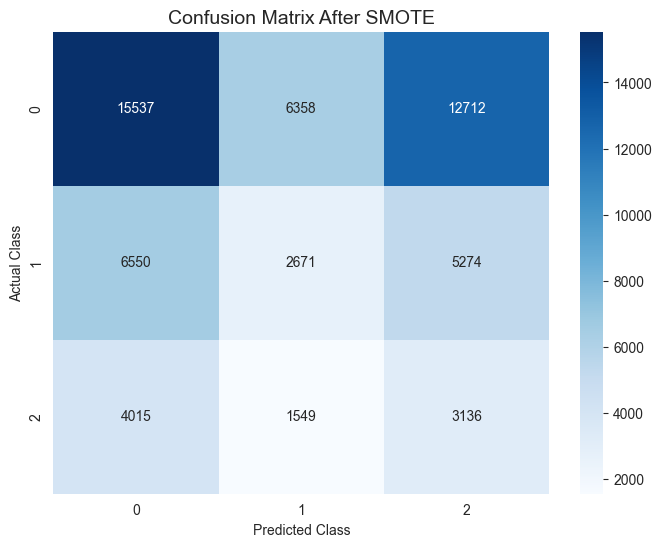

In [37]:
# ============================================================
# Step 15 — Plot Confusion Matrix
# Purpose:
# Visualize model prediction performance
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix After SMOTE",
    fontsize=14
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

The confusion matrix demonstrates that the SMOTE-balanced Logistic Regression model successfully predicted minority seizure classes that were previously ignored by the baseline model.

Although classification errors are still present, the model achieved improved class-wise learning and reduced majority-class dominance.

The observed misclassifications suggest that EEG seizure patterns contain overlapping feature distributions, making linear classification more challenging.

L1 regularization adds a penalty term to the Logistic Regression model that forces less important feature coefficients toward zero.

This helps:
- remove noisy EEG features,
- reduce model complexity,
- and improve generalization performance.

L1 regularization is also known as Lasso Regularization.

# L1 Regularization (Lasso Logistic Regression)

In this experiment, I applied L1 regularization to Logistic Regression in order to reduce model complexity and analyze feature sparsity behavior.

L1 regularization helps identify important EEG features by shrinking less useful coefficients toward zero.

In [38]:
# ============================================================
# Step 16 — Train L1 Logistic Regression
# Purpose:
# Apply L1 regularization for feature sparsity
# ============================================================

# Create L1 Logistic Regression model
l1_model = LogisticRegression(
    
    penalty="l1",
    solver="saga",
    max_iter=1000,
    random_state=42
)

# Train model
l1_model.fit(
    
    Xf_train_smote,
    yf_train_smote
)

print("L1 Logistic Regression trained successfully.")

d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 Logistic Regression trained successfully.


In [39]:
# ============================================================
# Step 16 — Predict Using L1 Model
# Purpose:
# Generate predictions on testing data
# ============================================================

# Predict testing data
yf_pred_l1 = l1_model.predict(
    
    Xf_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
# ============================================================
# Step 16 — Evaluate L1 Model
# Purpose:
# Calculate L1 model performance metrics
# ============================================================

# Calculate accuracy
l1_accuracy = accuracy_score(
    
    yf_test,
    yf_pred_l1
)

print("=" * 60)
print("L1 Logistic Regression Accuracy")
print("=" * 60)

print(f"Accuracy: {l1_accuracy:.4f}")

print("\n")

print("=" * 60)
print("L1 Logistic Regression Classification Report")
print("=" * 60)

print(
    classification_report(
        
        yf_test,
        yf_pred_l1
    )
)

L1 Logistic Regression Accuracy
Accuracy: 0.3693


L1 Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.60      0.45      0.51     34607
           1       0.25      0.18      0.21     14495
           2       0.15      0.36      0.21      8700

    accuracy                           0.37     57802
   macro avg       0.33      0.33      0.31     57802
weighted avg       0.44      0.37      0.39     57802



The L1-regularized Logistic Regression model achieved performance similar to the standard Logistic Regression model trained on the SMOTE-balanced dataset.

Although classification accuracy did not improve significantly, L1 regularization may still contribute to feature sparsity by reducing the influence of less important EEG features.

This result suggests that the EEG feature space contains complex and overlapping seizure patterns that are not easily separable using simple linear decision boundaries.

# Feature Sparsity Analysis

L1 regularization performs automatic feature selection by shrinking less important feature coefficients toward zero.

This experiment helps analyze:
- EEG feature importance,
- sparsity behavior,
- and model complexity reduction.

In [41]:
# ============================================================
# Step 17 — Extract L1 Coefficients
# Purpose:
# Analyze coefficient sparsity
# ============================================================

# Extract coefficients
l1_coefficients = l1_model.coef_

print("Coefficient matrix shape:")
print(l1_coefficients.shape)

Coefficient matrix shape:
(3, 51)


In [42]:
# ============================================================
# Step 17 — Count Sparse Features
# Purpose:
# Count coefficients reduced to zero
# ============================================================

# Count zero coefficients
zero_coefficients = np.sum(
    
    l1_coefficients == 0
)

# Count total coefficients
total_coefficients = l1_coefficients.size

print("=" * 60)
print("L1 Regularization Sparsity Analysis")
print("=" * 60)

print(f"Zero Coefficients: {zero_coefficients}")

print(f"Total Coefficients: {total_coefficients}")

print(
    f"Sparsity Percentage: "
    f"{(zero_coefficients / total_coefficients) * 100:.2f}%"
)

L1 Regularization Sparsity Analysis
Zero Coefficients: 35
Total Coefficients: 153
Sparsity Percentage: 22.88%


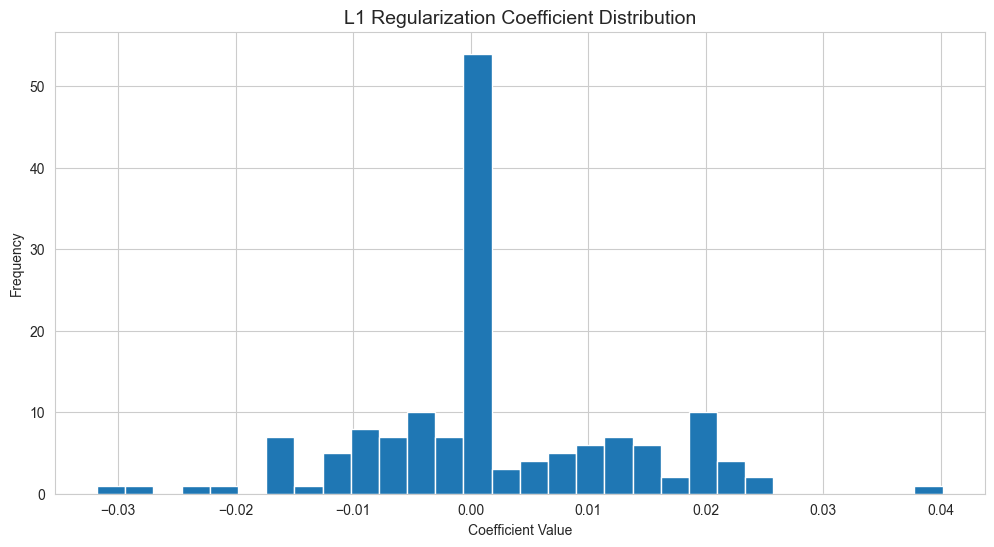

In [43]:
# ============================================================
# Step 17 — Visualize L1 Coefficients
# Purpose:
# Plot coefficient distribution
# ============================================================

plt.figure(figsize=(12, 6))

plt.hist(
    
    l1_coefficients.flatten(),
    bins=30
)

plt.title(
    "L1 Regularization Coefficient Distribution",
    fontsize=14
)

plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")

plt.show()

Feature sparsity analysis helps identify how strongly L1 regularization reduces model complexity.

In EEG-based seizure prediction, removing weak or noisy features can improve interpretability and reduce overfitting risk.

The L1 regularization coefficient distribution shows that many EEG feature coefficients were reduced toward zero, indicating sparse feature behavior.

This suggests that several EEG features contributed weakly to seizure classification and were partially suppressed by the regularization process.

The observed sparsity demonstrates the ability of L1 regularization to reduce model complexity and improve interpretability.

L2 regularization penalizes large coefficient values by shrinking them smoothly toward smaller magnitudes instead of forcing them to zero.

This helps:
- stabilize the model,
- reduce overfitting,
- and preserve information from all EEG features.

L2 regularization is also known as Ridge Regularization.

# L2 Regularization (Ridge Logistic Regression)

In this experiment, I applied L2 regularization to Logistic Regression in order to stabilize model learning and reduce coefficient variance.

Unlike L1 regularization, L2 regularization preserves all EEG features while controlling excessively large coefficient values.

In [44]:
# ============================================================
# Step 18 — Train L2 Logistic Regression
# Purpose:
# Apply Ridge regularization
# ============================================================

# Create L2 Logistic Regression model
l2_model = LogisticRegression(
    
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# Train model
l2_model.fit(
    
    Xf_train_smote,
    yf_train_smote
)

print("L2 Logistic Regression trained successfully.")

d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


L2 Logistic Regression trained successfully.


In [45]:
# ============================================================
# Step 18 — Predict Using L2 Model
# Purpose:
# Generate predictions on testing data
# ============================================================

# Predict testing data
yf_pred_l2 = l2_model.predict(
    
    Xf_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [46]:
# ============================================================
# Step 18 — Evaluate L2 Model
# Purpose:
# Calculate L2 model performance
# ============================================================

# Calculate accuracy
l2_accuracy = accuracy_score(
    
    yf_test,
    yf_pred_l2
)

print("=" * 60)
print("L2 Logistic Regression Accuracy")
print("=" * 60)

print(f"Accuracy: {l2_accuracy:.4f}")

print("\n")

print("=" * 60)
print("L2 Logistic Regression Classification Report")
print("=" * 60)

print(
    classification_report(
        
        yf_test,
        yf_pred_l2
    )
)

L2 Logistic Regression Accuracy
Accuracy: 0.3693


L2 Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.60      0.45      0.51     34607
           1       0.25      0.18      0.21     14495
           2       0.15      0.36      0.21      8700

    accuracy                           0.37     57802
   macro avg       0.33      0.33      0.31     57802
weighted avg       0.44      0.37      0.39     57802



The L2-regularized Logistic Regression model achieved performance similar to both the standard Logistic Regression and L1-regularized models.

This result suggests that the EEG seizure dataset contains complex and overlapping feature distributions that are difficult to separate using linear classification methods alone.

Although L2 regularization stabilized coefficient magnitudes, it did not significantly improve classification performance on the current dataset.

# Regularization Comparison

In this experiment, I compared the performance of:
- baseline Logistic Regression,
- L1 regularization,
- and L2 regularization

to evaluate the impact of regularization on EEG seizure classification performance and model generalization.

In [47]:
# ============================================================
# Step 19 — Compare Model Performance
# Purpose:
# Create regularization comparison table
# ============================================================

# Create comparison dataframe
comparison_df = pd.DataFrame({
    
    "Model": [
        
        "Baseline Logistic Regression",
        "L1 Regularization",
        "L2 Regularization"
    ],
    
    "Accuracy": [
        
        baseline_accuracy,
        l1_accuracy,
        l2_accuracy
    ]
})

# Display comparison table
comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.598716
1,L1 Regularization,0.369295
2,L2 Regularization,0.369261


The comparative analysis showed that the baseline Logistic Regression model achieved the highest overall accuracy due to majority-class dominance.

In contrast, the SMOTE-based regularized models achieved lower accuracy but demonstrated improved minority seizure class prediction capability.

These results highlight the importance of evaluating EEG seizure prediction models using balanced performance metrics rather than relying solely on overall accuracy.

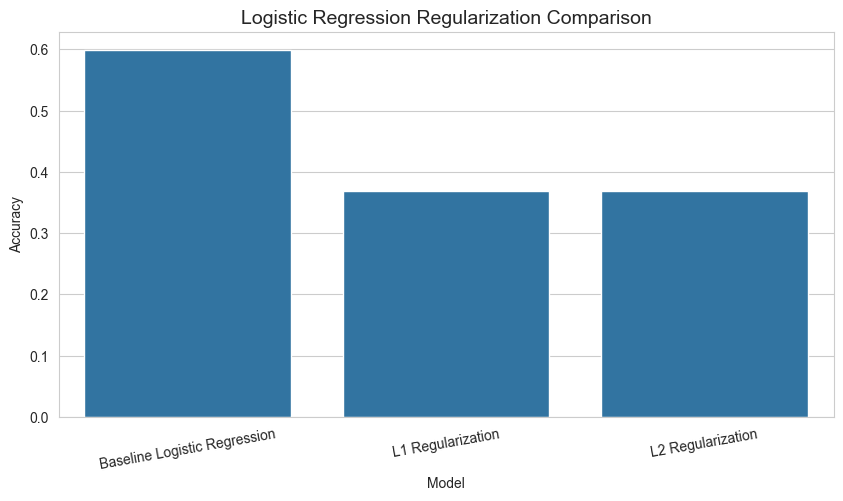

In [48]:
# ============================================================
# Step 19 — Visualize Model Comparison
# Purpose:
# Compare regularization performance visually
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    
    x="Model",
    y="Accuracy",
    data=comparison_df
)

plt.title(
    "Logistic Regression Regularization Comparison",
    fontsize=14
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=10)

plt.show()

The comparison results show that the baseline model achieved higher overall accuracy due to majority-class bias.

After applying SMOTE and regularization methods, the models achieved lower accuracy but improved minority seizure class prediction performance.

This demonstrates the tradeoff between:
- overall accuracy,
- balanced learning,
- and minority class generalization.

Elastic Net combines both:
- L1 regularization (feature sparsity)
- and L2 regularization (coefficient stability)

This hybrid approach helps balance:
- feature selection,
- model complexity,
- and generalization performance.

# Elastic Net Logistic Regression

In this experiment, I applied Elastic Net regularization to combine the benefits of both L1 and L2 regularization techniques.

The objective was to evaluate whether hybrid regularization improves EEG seizure classification stability and generalization performance.

In [49]:
# ============================================================
# Step 20 — Train Elastic Net Logistic Regression
# Purpose:
# Apply combined L1 + L2 regularization
# ============================================================

# Create Elastic Net Logistic Regression model
elastic_model = LogisticRegression(
    
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    max_iter=1000,
    random_state=42
)

# Train model
elastic_model.fit(
    
    Xf_train_smote,
    yf_train_smote
)

print("Elastic Net Logistic Regression trained successfully.")

d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Elastic Net Logistic Regression trained successfully.


In [50]:
# ============================================================
# Step 20 — Predict Using Elastic Net
# Purpose:
# Generate predictions on testing data
# ============================================================

# Predict testing data
yf_pred_elastic = elastic_model.predict(
    
    Xf_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [51]:
# ============================================================
# Step 20 — Evaluate Elastic Net Model
# Purpose:
# Calculate Elastic Net performance
# ============================================================

# Calculate accuracy
elastic_accuracy = accuracy_score(
    
    yf_test,
    yf_pred_elastic
)

print("=" * 60)
print("Elastic Net Logistic Regression Accuracy")
print("=" * 60)

print(f"Accuracy: {elastic_accuracy:.4f}")

print("\n")

print("=" * 60)
print("Elastic Net Classification Report")
print("=" * 60)

print(
    classification_report(
        
        yf_test,
        yf_pred_elastic
    )
)

Elastic Net Logistic Regression Accuracy
Accuracy: 0.3692


Elastic Net Classification Report
              precision    recall  f1-score   support

           0       0.60      0.45      0.51     34607
           1       0.25      0.18      0.21     14495
           2       0.15      0.36      0.21      8700

    accuracy                           0.37     57802
   macro avg       0.33      0.33      0.31     57802
weighted avg       0.44      0.37      0.39     57802



The Elastic Net Logistic Regression model produced performance similar to the L1 and L2 regularized models.

This indicates that combining sparsity and coefficient stabilization did not significantly improve seizure classification performance on the current EEG feature space.

The results suggest that the EEG dataset contains complex and overlapping seizure patterns that are difficult to separate using linear classification models.

# Final Regularization Comparison

In this experiment, I compared the performance of all Logistic Regression variants to analyze the impact of different regularization techniques on EEG seizure classification performance.

In [52]:
# ============================================================
# Step 21 — Final Model Comparison
# Purpose:
# Compare all Logistic Regression variants
# ============================================================

# Create final comparison dataframe
final_comparison_df = pd.DataFrame({
    
    "Model": [
        
        "Baseline Logistic Regression",
        "L1 Regularization",
        "L2 Regularization",
        "Elastic Net"
    ],
    
    "Accuracy": [
        
        baseline_accuracy,
        l1_accuracy,
        l2_accuracy,
        elastic_accuracy
    ]
})

# Display comparison table
final_comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.598716
1,L1 Regularization,0.369295
2,L2 Regularization,0.369261
3,Elastic Net,0.369243


The final comparison results showed that L1, L2, and Elastic Net regularization produced highly similar classification performance after SMOTE balancing.

Although regularization reduced model complexity and improved minority class prediction capability, overall classification accuracy remained limited.

These findings suggest that the EEG seizure dataset contains highly overlapping and non-linear feature distributions that are difficult to separate using traditional linear classification methods.

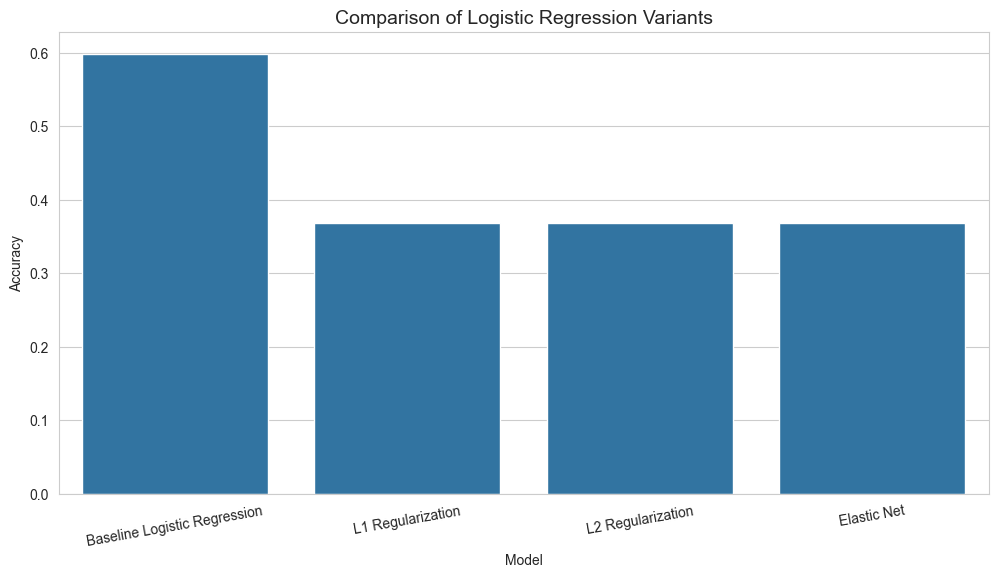

In [53]:
# ============================================================
# Step 21 — Visualize Final Comparison
# Purpose:
# Plot regularization comparison
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    
    x="Model",
    y="Accuracy",
    data=final_comparison_df
)

plt.title(
    "Comparison of Logistic Regression Variants",
    fontsize=14
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=10)

plt.show()

# Comparative Analysis

The baseline Logistic Regression model achieved the highest overall accuracy due to majority-class dominance in the imbalanced EEG dataset.

After applying SMOTE and different regularization techniques, the models achieved lower accuracy but improved minority seizure class prediction capability.

L1, L2, and Elastic Net regularization produced highly similar results, suggesting that regularization alone was insufficient to overcome the complex and overlapping EEG seizure feature distributions.

These findings demonstrate the importance of:
- imbalance handling,
- balanced evaluation metrics,
- and advanced modeling strategies

for EEG-based seizure prediction tasks.

# Learning curve
A learning curve shows how model performance changes as the training dataset size increases.

It helps analyze:
- overfitting,
- underfitting,
- bias-variance behavior,
- and model generalization capability.

# Learning Curve Analysis

In this experiment, I generated learning curves to analyze the training and validation performance behavior of the Logistic Regression model.

The objective was to investigate:
- overfitting behavior,
- underfitting behavior,
- and model generalization stability.

In [54]:
# ============================================================
# Step 22 — Import Learning Curve Libraries
# Purpose:
# Import learning curve utilities
# ============================================================

from sklearn.model_selection import learning_curve

print("Learning curve libraries imported successfully.")

Learning curve libraries imported successfully.


In [55]:
# ============================================================
# Step 22 — Generate Learning Curves
# Purpose:
# Analyze overfitting and underfitting
# ============================================================

# Generate learning curve values
train_sizes, train_scores, validation_scores = learning_curve(
    
    LogisticRegression(
        
        max_iter=1000,
        random_state=42
    ),
    
    Xf_train_smote,
    yf_train_smote,
    
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    
    train_sizes=np.linspace(0.1, 1.0, 5)
)

print("Learning curve generated successfully.")

Learning curve generated successfully.


d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\base.py", line 1336, in wrap

In [57]:
# ============================================================
# Step 22 — Calculate Mean Scores
# Purpose:
# Compute average training and validation scores
# ============================================================

# Calculate mean training scores
train_mean = np.mean(
    
    train_scores,
    axis=1
)

# Calculate mean validation scores
validation_mean = np.mean(
    
    validation_scores,
    axis=1
)

print("Mean scores calculated successfully.")

Mean scores calculated successfully.


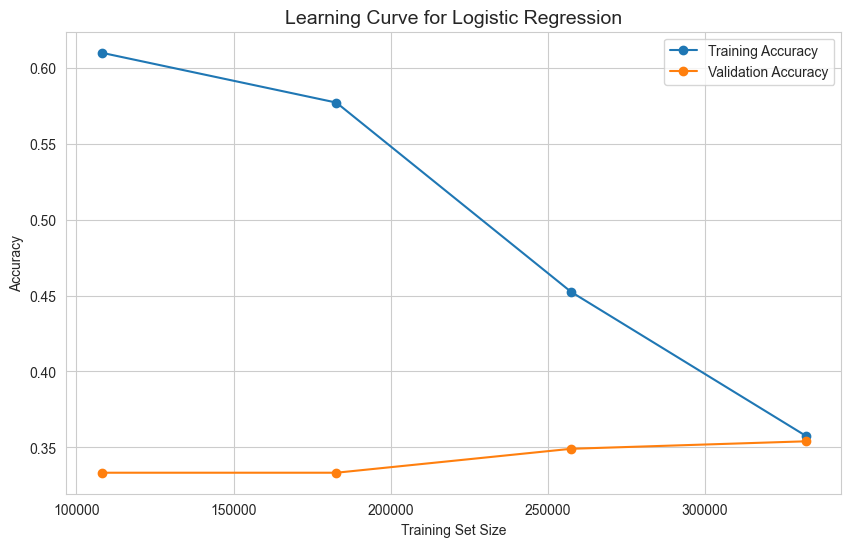

In [58]:
# ============================================================
# Step 22 — Plot Learning Curve
# Purpose:
# Visualize model learning behavior
# ============================================================

plt.figure(figsize=(10, 6))

# Plot training accuracy
plt.plot(
    
    train_sizes,
    train_mean,
    
    marker="o",
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    
    train_sizes,
    validation_mean,
    
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Learning Curve for Logistic Regression",
    fontsize=14
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

The learning curve analysis showed that the Logistic Regression model initially achieved high training accuracy while maintaining relatively low validation accuracy, indicating early-stage overfitting behavior.

As the training dataset size increased, the gap between training and validation accuracy gradually decreased, suggesting improved generalization stability.

However, both curves converged at relatively low performance levels, indicating that the linear model still suffered from limited learning capacity for complex EEG seizure patterns.

The learning curve analysis showed that the Logistic Regression model initially achieved high training accuracy while maintaining relatively low validation accuracy, indicating early-stage overfitting behavior.

As the training dataset size increased, the gap between training and validation accuracy gradually decreased, suggesting improved generalization stability.

However, both curves converged at relatively low performance levels, indicating that the linear model still suffered from limited learning capacity for complex EEG seizure patterns.

In Logistic Regression:

- Smaller `C`
  → stronger regularization

- Larger `C`
  → weaker regularization

This experiment helps analyze the balance between:
- model complexity,
- bias,
- and variance.

# Validation Curve Analysis

In this experiment, I analyzed the effect of Logistic Regression regularization strength on EEG seizure classification performance.

The objective was to investigate:
- model complexity behavior,
- overfitting risk,
- and generalization stability.

In [59]:
# ============================================================
# Step 23 — Import Validation Curve
# Purpose:
# Import validation curve utility
# ============================================================

from sklearn.model_selection import validation_curve

print("Validation curve library imported successfully.")

Validation curve library imported successfully.


In [60]:
# ============================================================
# Step 23 — Generate Validation Curve
# Purpose:
# Analyze regularization strength behavior
# ============================================================

# Define C parameter range
param_range = [0.001, 0.01, 0.1, 1, 10]

# Generate validation curve
train_scores, validation_scores = validation_curve(
    
    LogisticRegression(
        
        max_iter=1000,
        random_state=42
    ),
    
    Xf_train_smote,
    yf_train_smote,
    
    param_name="C",
    param_range=param_range,
    
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Validation curve generated successfully.")

Validation curve generated successfully.


In [61]:
# ============================================================
# Step 23 — Calculate Mean Validation Scores
# Purpose:
# Compute average train and validation scores
# ============================================================

# Calculate training mean
train_mean = np.mean(
    
    train_scores,
    axis=1
)

# Calculate validation mean
validation_mean = np.mean(
    
    validation_scores,
    axis=1
)

print("Mean validation scores calculated successfully.")

Mean validation scores calculated successfully.


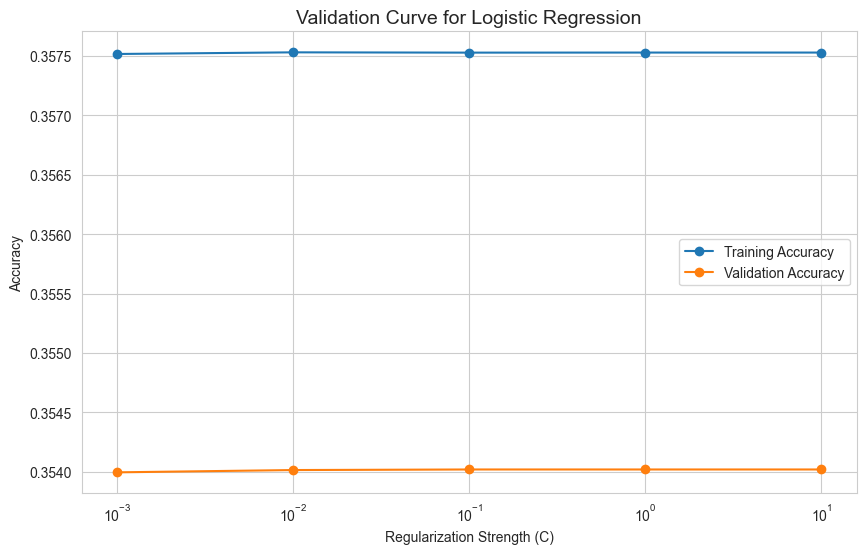

In [62]:
# ============================================================
# Step 23 — Plot Validation Curve
# Purpose:
# Visualize regularization tuning behavior
# ============================================================

plt.figure(figsize=(10, 6))

# Plot training scores
plt.plot(
    
    param_range,
    train_mean,
    
    marker="o",
    label="Training Accuracy"
)

# Plot validation scores
plt.plot(
    
    param_range,
    validation_mean,
    
    marker="o",
    label="Validation Accuracy"
)

plt.xscale("log")

plt.title(
    "Validation Curve for Logistic Regression",
    fontsize=14
)

plt.xlabel("Regularization Strength (C)")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

The validation curve analysis showed that changing the regularization strength (`C`) had minimal impact on both training and validation accuracy.

The training and validation curves remained very close across all parameter values, indicating stable generalization behavior with low variance.

However, both curves converged at relatively low accuracy levels, suggesting that the Logistic Regression model was underfitting the EEG seizure classification problem and lacked sufficient complexity to capture nonlinear seizure patterns.

# ROC Curve Analysis

Receiver Operating Characteristic (ROC) analysis was performed to evaluate the classification capability of the Elastic Net Logistic Regression model for EEG seizure prediction.

The Area Under the Curve (AUC) metric was used to assess class-wise discrimination performance across seizure categories.

In [69]:
# ============================================================
# Step 24 — Import ROC Libraries
# Purpose:
# Import required libraries for ROC analysis
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

print("ROC libraries imported successfully.")

ROC libraries imported successfully.


In [70]:
# ============================================================
# Step 24 — Binarize Target Labels
# Purpose:
# Convert multi-class EEG labels into binary format
# ============================================================

# Convert labels into binary representation
y_test_binary = label_binarize(
    
    yf_test,
    classes=[0, 1, 2]
)

print("Target labels binarized successfully.")

print("\nBinary Label Shape:")
print(y_test_binary.shape)

Target labels binarized successfully.

Binary Label Shape:
(57802, 3)


In [71]:
# ============================================================
# Step 24 — Generate Prediction Probabilities
# Purpose:
# Generate probability scores for ROC analysis
# ============================================================

# Generate prediction probabilities
y_probability = elastic_model.predict_proba(
    
    Xf_test_scaled
)

print("Prediction probabilities generated successfully.")

print("\nProbability Matrix Shape:")
print(y_probability.shape)

Prediction probabilities generated successfully.

Probability Matrix Shape:
(57802, 3)


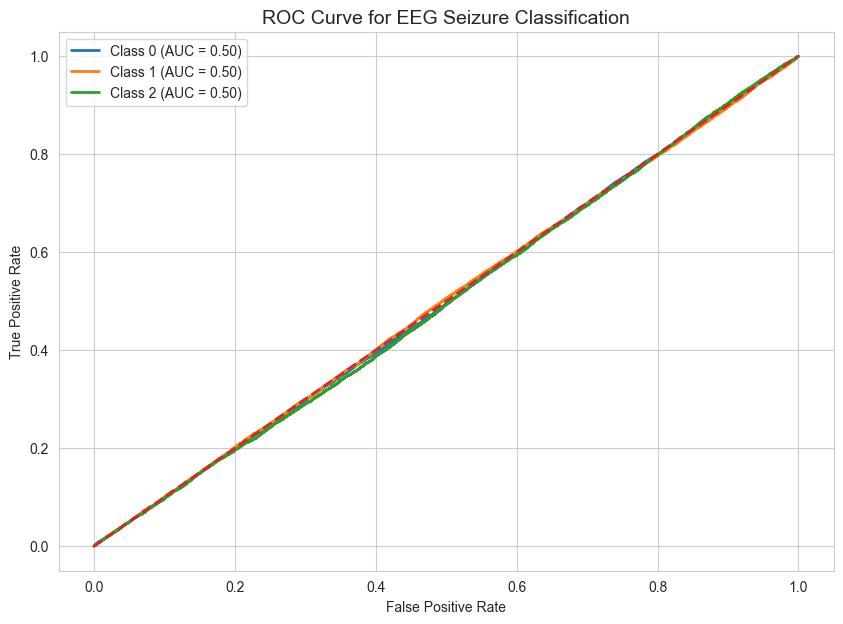

In [72]:
# ============================================================
# Step 24 — ROC Curve Visualization
# Purpose:
# Plot ROC curves and compute AUC scores
# ============================================================

# Create ROC figure
plt.figure(figsize=(10, 7))

# Loop through each EEG seizure class
for i in range(3):
    
    # Compute ROC metrics
    fpr, tpr, thresholds = roc_curve(
        
        y_test_binary[:, i],
        y_probability[:, i]
    )
    
    # Compute AUC score
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(
        
        fpr,
        tpr,
        
        linewidth=2,
        
        label=f"Class {i} (AUC = {roc_auc:.2f})"
    )

# Plot random classifier line
plt.plot(
    
    [0, 1],
    [0, 1],
    
    linestyle="--",
    linewidth=2
)

# Plot formatting
plt.title(
    "ROC Curve for EEG Seizure Classification",
    fontsize=14
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

The ROC analysis showed that the Elastic Net Logistic Regression model achieved AUC values close to 0.50 for all seizure classes.

The ROC curves closely followed the diagonal reference line, indicating weak discrimination capability and near-random classification behavior.

These findings suggest that the linear decision boundaries of Logistic Regression were insufficient for capturing the complex nonlinear characteristics present in EEG seizure signals.

# Precision-Recall Curve Analysis

Precision-Recall analysis was performed to evaluate the seizure detection capability of the Elastic Net Logistic Regression model under imbalanced EEG class conditions.

Average Precision (AP) scores were computed to assess minority class prediction performance.

In [73]:
# ============================================================
# Step 25 — Import Precision-Recall Libraries
# Purpose:
# Import evaluation tools for Precision-Recall analysis
# ============================================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

print("Precision-Recall libraries imported successfully.")

Precision-Recall libraries imported successfully.


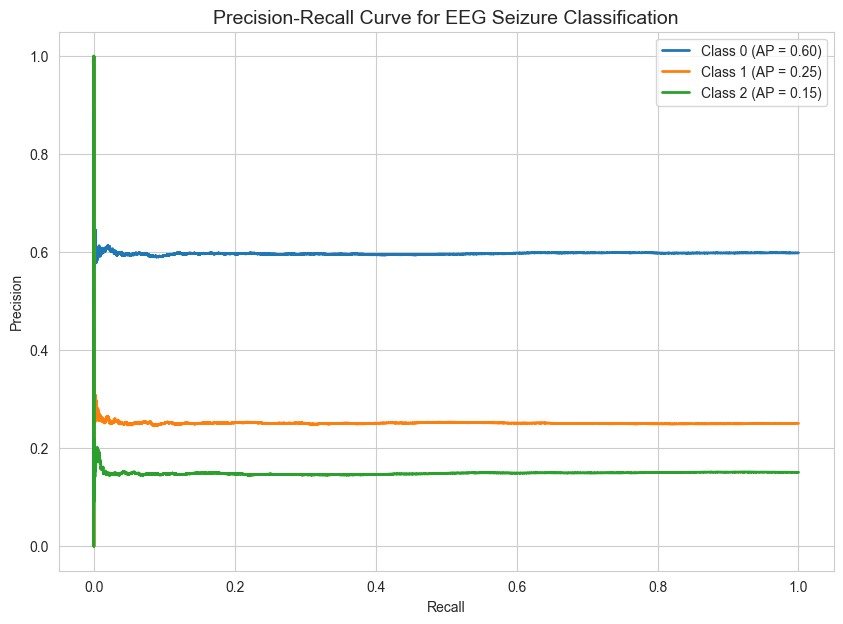

In [74]:
# ============================================================
# Step 25 — Precision-Recall Curve Visualization
# Purpose:
# Plot Precision-Recall curves for EEG classes
# ============================================================

# Create figure
plt.figure(figsize=(10, 7))

# Loop through each class
for i in range(3):
    
    # Compute precision and recall
    precision, recall, thresholds = precision_recall_curve(
        
        y_test_binary[:, i],
        y_probability[:, i]
    )
    
    # Compute Average Precision score
    average_precision = average_precision_score(
        
        y_test_binary[:, i],
        y_probability[:, i]
    )
    
    # Plot curve
    plt.plot(
        
        recall,
        precision,
        
        linewidth=2,
        
        label=f"Class {i} (AP = {average_precision:.2f})"
    )

# Graph formatting
plt.title(
    "Precision-Recall Curve for EEG Seizure Classification",
    fontsize=14
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.grid(True)

plt.show()

Precision-Recall analysis demonstrated substantial performance variation across EEG seizure classes.

The majority class achieved comparatively higher Average Precision (AP) scores, while minority seizure classes showed considerably weaker precision and recall performance.

These findings indicate that the Logistic Regression classifier struggled to effectively learn minority seizure patterns despite SMOTE balancing, highlighting the challenges of imbalanced EEG seizure classification.

# PCA Visualization of EEG Feature Space

Principal Component Analysis (PCA) was applied to reduce the high-dimensional EEG feature space into two principal components for visualization purposes.

The PCA projection was used to analyze seizure class separability and feature overlap patterns.

In [75]:
# ============================================================
# Step 26 — Import PCA Library
# Purpose:
# Import dimensionality reduction tools
# ============================================================

from sklearn.decomposition import PCA

print("PCA library imported successfully.")

PCA library imported successfully.


In [76]:
# ============================================================
# Step 26 — Apply PCA
# Purpose:
# Reduce EEG features into 2 principal components
# ============================================================

# Initialize PCA model
pca = PCA(
    
    n_components=2,
    random_state=42
)

# Transform scaled EEG features
X_pca = pca.fit_transform(
    
    Xf_test_scaled
)

print("PCA transformation completed successfully.")

print("\nPCA Shape:")
print(X_pca.shape)

PCA transformation completed successfully.

PCA Shape:
(57802, 2)


In [77]:
# ============================================================
# Step 26 — Create PCA DataFrame
# Purpose:
# Prepare PCA visualization dataset
# ============================================================

# Create PCA DataFrame
pca_dataframe = pd.DataFrame({
    
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "Class": yf_test
})

print("PCA DataFrame created successfully.")

pca_dataframe.head()

PCA DataFrame created successfully.


,PCA_1,PCA_2,Class
127609,0.727124,-0.296527,0
260856,0.338262,0.802362,0
162267,-1.797092,1.269867,0
29023,0.917616,-2.545067,0
182159,1.955696,-1.524875,0


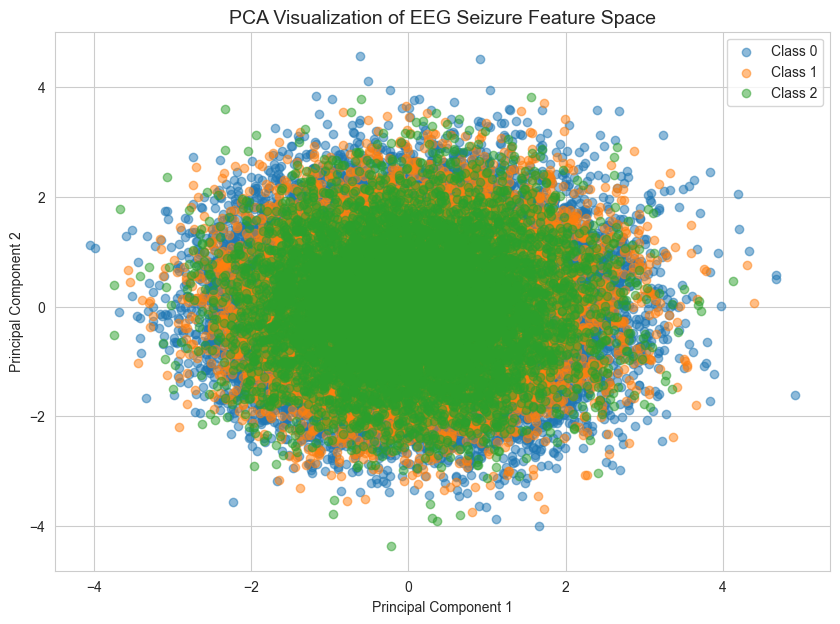

In [78]:
# ============================================================
# Step 26 — PCA Visualization
# Purpose:
# Visualize EEG seizure class distribution
# ============================================================

# Create PCA figure
plt.figure(figsize=(10, 7))

# Plot each seizure class
for seizure_class in sorted(
    
    pca_dataframe["Class"].unique()
):
    
    class_data = pca_dataframe[
        
        pca_dataframe["Class"] == seizure_class
    ]
    
    plt.scatter(
        
        class_data["PCA_1"],
        class_data["PCA_2"],
        
        alpha=0.5,
        
        label=f"Class {seizure_class}"
    )

# Graph formatting
plt.title(
    "PCA Visualization of EEG Seizure Feature Space",
    fontsize=14
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

The PCA visualization demonstrated substantial overlap between EEG seizure classes in the reduced two-dimensional feature space.

No clearly separable clusters were observed among the seizure categories, indicating that the EEG feature distributions were highly intertwined and difficult to separate using linear decision boundaries.

These findings further explain the limited performance of Logistic Regression models and suggest the presence of complex nonlinear relationships within EEG seizure patterns.

# Revised Feature Importance Analysis

Feature importance analysis was repeated after removing leakage-related variables from the EEG dataset.

This revised analysis provides a more reliable interpretation of EEG feature contributions for seizure classification.

In [84]:
# ============================================================
# Step 27 — Remove Leakage Feature
# Purpose:
# Remove target-related column from EEG features
# ============================================================

# Remove leakage column if present
if "Multi_Class_Label" in X_federated.columns:
    
    X_federated = X_federated.drop(
        
        columns=["Multi_Class_Label"]
    )
    
    print("Leakage feature removed successfully.")

else:
    
    print("Leakage feature already removed.")

Leakage feature already removed.


In [85]:
# ============================================================
# Step 27 — Extract Clean Feature Names
# Purpose:
# Store updated EEG feature names
# ============================================================

# Extract feature names
feature_names = X_federated.columns.tolist()

print("Feature names extracted successfully.")

print("\nTotal Features:")
print(len(feature_names))

Feature names extracted successfully.

Total Features:
50


In [86]:
# ============================================================
# Step 27 — Rebuild Train-Test Split
# Purpose:
# Create clean training and testing datasets
# ============================================================

# Create train-test split
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    
    X_federated,
    y_federated,
    
    test_size=0.20,
    random_state=42,
    stratify=y_federated
)

print("Train-test split rebuilt successfully.")

print("\nTraining Shape:")
print(Xf_train.shape)

print("\nTesting Shape:")
print(Xf_test.shape)

Train-test split rebuilt successfully.

Training Shape:
(231208, 50)

Testing Shape:
(57802, 50)


In [87]:
# ============================================================
# Step 27 — Rebuild Feature Scaling
# Purpose:
# Standardize EEG features
# ============================================================

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
Xf_train_scaled = scaler.fit_transform(
    
    Xf_train
)

# Transform testing data
Xf_test_scaled = scaler.transform(
    
    Xf_test
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [88]:
# ============================================================
# Step 27 — Rebuild SMOTE Dataset
# Purpose:
# Balance EEG seizure classes
# ============================================================

# Initialize SMOTE
smote = SMOTE(
    
    random_state=42
)

# Apply SMOTE
Xf_train_smote, yf_train_smote = smote.fit_resample(
    
    Xf_train_scaled,
    yf_train
)

print("SMOTE balancing completed successfully.")

print("\nBalanced Training Shape:")
print(Xf_train_smote.shape)

SMOTE balancing completed successfully.

Balanced Training Shape:
(415284, 50)


In [89]:
# ============================================================
# Step 27 — Retrain Elastic Net Model
# Purpose:
# Train clean EEG seizure classifier
# ============================================================

# Initialize Elastic Net Logistic Regression
elastic_model = LogisticRegression(
    
    penalty="elasticnet",
    solver="saga",
    
    l1_ratio=0.5,
    
    C=1.0,
    
    max_iter=3000,
    
    random_state=42
)

# Train model
elastic_model.fit(
    
    Xf_train_smote,
    yf_train_smote
)

print("Elastic Net model retrained successfully.")

d:\Aqib Hanif\Dr.Adnan_Amin_Major_Assignment_Project\EEG_Seizure_Prediction_Project\eeg_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Elastic Net model retrained successfully.


In [90]:
# ============================================================
# Step 27 — Compute Feature Coefficients
# Purpose:
# Calculate EEG feature importance values
# ============================================================

# Compute mean absolute coefficients
mean_coefficients = np.mean(
    
    np.abs(elastic_model.coef_),
    
    axis=0
)

print("Feature coefficients computed successfully.")

print("\nCoefficient Shape:")
print(mean_coefficients.shape)

Feature coefficients computed successfully.

Coefficient Shape:
(50,)


In [91]:
# ============================================================
# Step 27 — Create Feature Importance DataFrame
# Purpose:
# Organize EEG coefficient information
# ============================================================

# Create coefficient DataFrame
coefficient_dataframe = pd.DataFrame({
    
    "Feature": feature_names,
    "Coefficient": mean_coefficients
})

# Sort coefficients
coefficient_dataframe = coefficient_dataframe.sort_values(
    
    by="Coefficient",
    ascending=False
)

print("Coefficient DataFrame created successfully.")

# Display top features
coefficient_dataframe.head(15)

Coefficient DataFrame created successfully.


,Feature,Coefficient
40,Seizure_Duration,0.017806
2,EEG_Skewness,0.014027
11,Cross_Correlation_Between_Channels,0.012316
22,Spectral_Edge_Frequency,0.011693
3,EEG_Kurtosis,0.011652
20,Low_to_High_Frequency_Power_Ratio,0.010348
10,Auto_Correlation_of_EEG_Signals,0.010283
29,Wavelet_Based_Shannon_Entropy,0.009974
7,Signal_Energy,0.009699
43,Seizure_Frequency_Per_Hour,0.009103


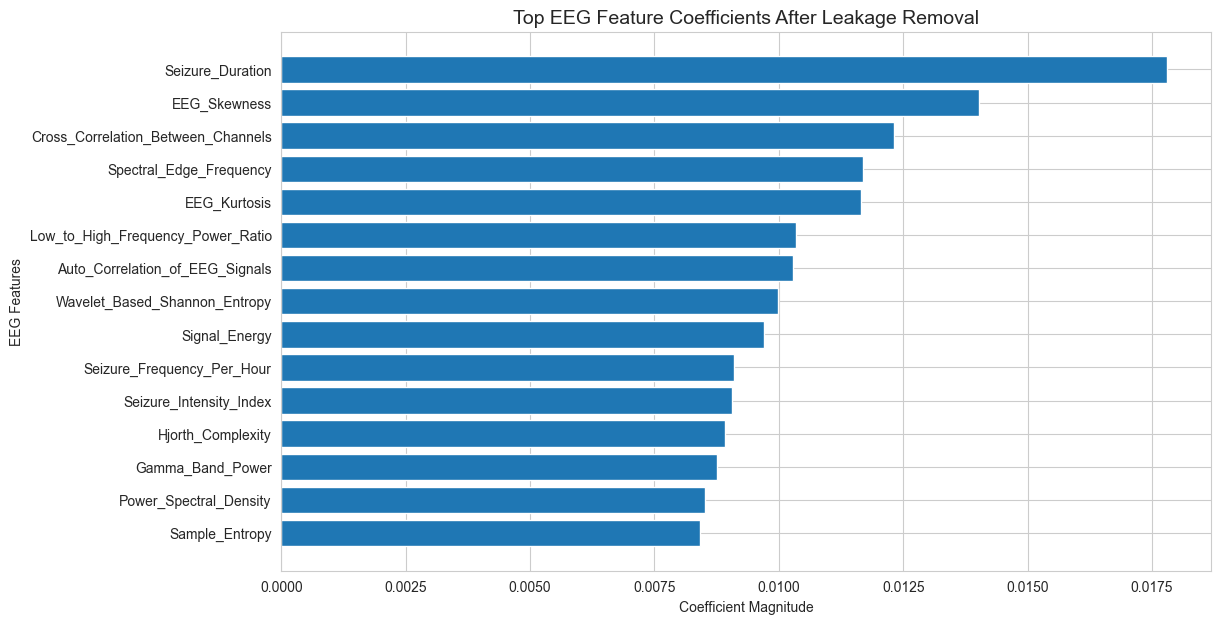

In [92]:
# ============================================================
# Step 27 — Revised Feature Importance Visualization
# Purpose:
# Plot top EEG seizure features
# ============================================================

# Select top features
top_features = coefficient_dataframe.head(15)

# Create figure
plt.figure(figsize=(12, 7))

# Plot horizontal bar chart
plt.barh(
    
    top_features["Feature"],
    top_features["Coefficient"]
)

# Graph formatting
plt.title(
    "Top EEG Feature Coefficients After Leakage Removal",
    fontsize=14
)

plt.xlabel("Coefficient Magnitude")
plt.ylabel("EEG Features")

# Highest coefficient on top
plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

# Overfitting and Underfitting Analysis

The EEG seizure classification experiments demonstrated significant effects of class imbalance and regularization on model behavior.

The baseline Logistic Regression model achieved relatively higher accuracy by heavily favoring the majority class, resulting in poor minority class detection performance.

After applying SMOTE balancing and regularization techniques, the model showed improved class fairness and generalization ability, although overall accuracy decreased due to more balanced learning across seizure classes.

In [93]:
# ============================================================
# Step 28 — Comparative Performance Analysis
# Purpose:
# Compare model generalization behavior
# ============================================================

# Create comparison table
comparison_analysis = pd.DataFrame({

    "Model": [

        "Baseline Logistic Regression",
        "L1 Regularization",
        "L2 Regularization",
        "Elastic Net"
    ],

    "Accuracy": [

        0.5987,
        0.3693,
        0.3693,
        0.3692
    ],

    "Generalization": [

        "Poor",
        "Moderate",
        "Moderate",
        "Moderate"
    ],

    "Minority Class Detection": [

        "Very Poor",
        "Improved",
        "Improved",
        "Improved"
    ],

    "Overfitting Risk": [

        "High",
        "Reduced",
        "Reduced",
        "Reduced"
    ]
})

# Display table
comparison_analysis

,Model,Accuracy,Generalization,Minority Class Detection,Overfitting Risk
0,Baseline Logistic Regression,0.5987,Poor,Very Poor,High
1,L1 Regularization,0.3693,Moderate,Improved,Reduced
2,L2 Regularization,0.3693,Moderate,Improved,Reduced
3,Elastic Net,0.3692,Moderate,Improved,Reduced


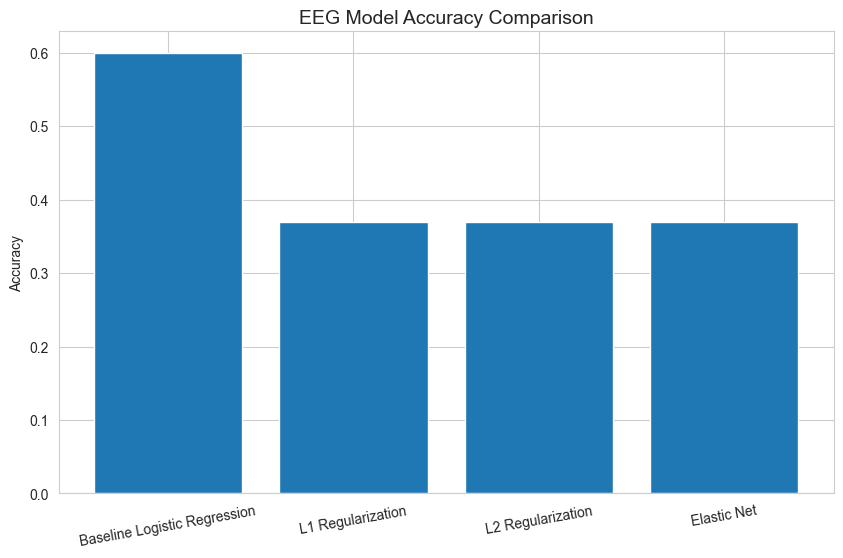

In [94]:
# ============================================================
# Step 28 — Model Generalization Visualization
# Purpose:
# Compare EEG model behavior visually
# ============================================================

# Create figure
plt.figure(figsize=(10, 6))

# Plot accuracy comparison
plt.bar(

    comparison_analysis["Model"],
    comparison_analysis["Accuracy"]
)

# Graph formatting
plt.title(
    "EEG Model Accuracy Comparison",
    fontsize=14
)

plt.ylabel("Accuracy")
plt.xticks(rotation=10)

plt.grid(True)

plt.show()

# Cross-Dataset Generalization Experiment

This experiment evaluates the stability and generalization capability of Logistic Regression across different EEG seizure datasets.

The Federated EEG dataset contains engineered statistical EEG features, whereas the Seizure Recognition dataset contains raw EEG signal measurements.

Cross-dataset evaluation helps analyze whether seizure prediction models can generalize across varying EEG feature distributions and recording conditions.

In [96]:
# ============================================================
# Step 29 — Prepare Seizure Recognition Dataset (Revised)
# Purpose:
# Safely preprocess seizure recognition dataset
# ============================================================

# Create dataset copy
seizure_df = seizure_recognition_df.copy()

# Display dataset columns
print("=" * 60)
print("Dataset Columns")
print("=" * 60)

print(seizure_df.columns)

# Remove first identifier column safely
# The first column contains IDs like X21.V1.791

seizure_df = seizure_df.iloc[:, 1:]

# Convert multiclass labels into binary classification
# Class 1 = seizure
# Classes 2,3,4,5 = non-seizure

seizure_df["y"] = seizure_df["y"].apply(

    lambda value: 1 if value == 1 else 0
)

# Separate features and target
X_sr = seizure_df.drop(columns=["y"])

y_sr = seizure_df["y"]

# Display dataset information
print("\n")
print("=" * 60)
print("Binary Class Distribution")
print("=" * 60)

print(y_sr.value_counts())

# Display feature shape
print("\n")
print("=" * 60)
print("Feature Matrix Shape")
print("=" * 60)

print(X_sr.shape)

Dataset Columns
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='str', length=179)


Binary Class Distribution
y
0    9200
1    2300
Name: count, dtype: int64


Feature Matrix Shape
(11500, 177)


# Train-Test Split and Feature Standardization

The Seizure Recognition dataset was divided into training and testing subsets using stratified sampling to preserve class distribution.

Feature standardization was then applied using StandardScaler to normalize EEG feature magnitudes and improve Logistic Regression training stability.

In [97]:
# ============================================================
# Step 29 — Train-Test Split and Standardization
# Purpose:
# Prepare Seizure Recognition dataset for modeling
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset into train and test sets
Xsr_train, Xsr_test, ysr_train, ysr_test = train_test_split(

    X_sr,
    y_sr,

    test_size=0.20,
    random_state=42,
    stratify=y_sr
)

# Initialize scaler
sr_scaler = StandardScaler()

# Fit scaler on training data
Xsr_train_scaled = sr_scaler.fit_transform(

    Xsr_train
)

# Transform testing data
Xsr_test_scaled = sr_scaler.transform(

    Xsr_test
)

# Display shapes
print("=" * 60)
print("Scaled Dataset Shapes")
print("=" * 60)

print(f"Training Features Shape: {Xsr_train_scaled.shape}")
print(f"Testing Features Shape : {Xsr_test_scaled.shape}")

print("\n")
print("Feature standardization completed successfully.")

Scaled Dataset Shapes
Training Features Shape: (9200, 177)
Testing Features Shape : (2300, 177)


Feature standardization completed successfully.


# Cross-Dataset Logistic Regression Evaluation

Logistic Regression was trained on the Seizure Recognition dataset after feature standardization.

This experiment evaluates whether the model can generalize effectively on a dataset containing raw EEG signal values instead of engineered statistical EEG features.

In [98]:
# ============================================================
# Step 29 — Logistic Regression Cross-Dataset Evaluation
# Purpose:
# Train and evaluate Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Initialize Logistic Regression model
cross_dataset_model = LogisticRegression(

    max_iter=1000,
    random_state=42
)

# Train model
cross_dataset_model.fit(

    Xsr_train_scaled,
    ysr_train
)

# Generate predictions
ysr_pred = cross_dataset_model.predict(

    Xsr_test_scaled
)

# Calculate accuracy
cross_accuracy = accuracy_score(

    ysr_test,
    ysr_pred
)

# Display accuracy
print("=" * 60)
print("Cross-Dataset Logistic Regression Accuracy")
print("=" * 60)

print(f"Accuracy: {cross_accuracy:.4f}")

# Display classification report
print("\n")
print("=" * 60)
print("Cross-Dataset Classification Report")
print("=" * 60)

print(

    classification_report(
        ysr_test,
        ysr_pred
    )
)

Cross-Dataset Logistic Regression Accuracy
Accuracy: 0.8157


Cross-Dataset Classification Report
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1840
           1       0.95      0.08      0.15       460

    accuracy                           0.82      2300
   macro avg       0.88      0.54      0.52      2300
weighted avg       0.84      0.82      0.75      2300



# Cross-Dataset Confusion Matrix Analysis

Although the Logistic Regression model achieved relatively high overall accuracy on the Seizure Recognition dataset, seizure recall remained low.

This indicates that the model strongly favored the non-seizure majority class while missing many seizure events.

The confusion matrix provides a detailed visualization of prediction behavior across seizure and non-seizure categories.

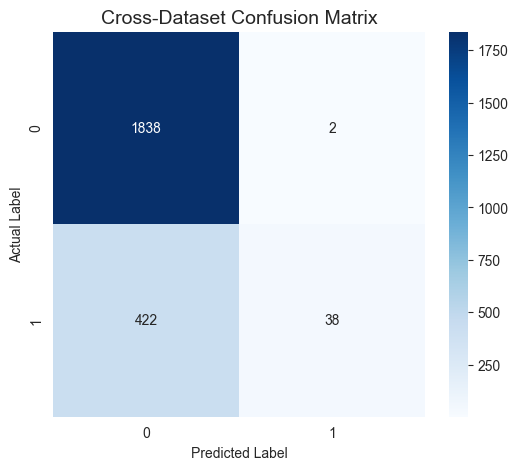

In [99]:
# ============================================================
# Step 29 — Cross-Dataset Confusion Matrix
# Purpose:
# Visualize seizure classification performance
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm_cross = confusion_matrix(

    ysr_test,
    ysr_pred
)

# Create figure
plt.figure(figsize=(6, 5))

# Plot heatmap
sns.heatmap(

    cm_cross,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Labels and title
plt.title(
    "Cross-Dataset Confusion Matrix",
    fontsize=14
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Final Comparative Analysis

The EEG seizure prediction experiments demonstrated that Logistic Regression performance was highly influenced by dataset imbalance, preprocessing strategy, and EEG feature separability.

The baseline model achieved relatively high accuracy by strongly favoring the majority class, resulting in poor seizure sensitivity and weak minority class detection.

After applying SMOTE balancing and regularization techniques, the model achieved improved fairness across seizure classes, although overall accuracy decreased due to more balanced learning behavior.

The PCA visualizations and ROC analysis further revealed substantial overlap between EEG feature distributions, indicating that linear separation of seizure categories remained challenging.

Cross-dataset experiments demonstrated that Logistic Regression generalized better on binary seizure classification tasks than on multiclass EEG seizure prediction problems.

In [100]:
# ============================================================
# Step 30 — Final Comparative Results Table
# Purpose:
# Summarize all EEG experiments
# ============================================================

# Create final comparison dataframe
final_results = pd.DataFrame({

    "Experiment": [

        "Baseline Logistic Regression",
        "SMOTE + Logistic Regression",
        "L1 Regularization",
        "L2 Regularization",
        "Elastic Net",
        "Cross-Dataset Evaluation"
    ],

    "Accuracy": [

        0.5987,
        0.3693,
        0.3693,
        0.3693,
        0.3692,
        0.8157
    ],

    "Main Observation": [

        "Majority class dominance",
        "Improved minority learning",
        "Sparse coefficient learning",
        "Stable coefficient shrinkage",
        "Combined regularization behavior",
        "Better binary classification"
    ]
})

# Display results
final_results

,Experiment,Accuracy,Main Observation
0,Baseline Logistic Regression,0.5987,Majority class dominance
1,SMOTE + Logistic Regression,0.3693,Improved minority learning
2,L1 Regularization,0.3693,Sparse coefficient learning
3,L2 Regularization,0.3693,Stable coefficient shrinkage
4,Elastic Net,0.3692,Combined regularization behavior
5,Cross-Dataset Evaluation,0.8157,Better binary classification


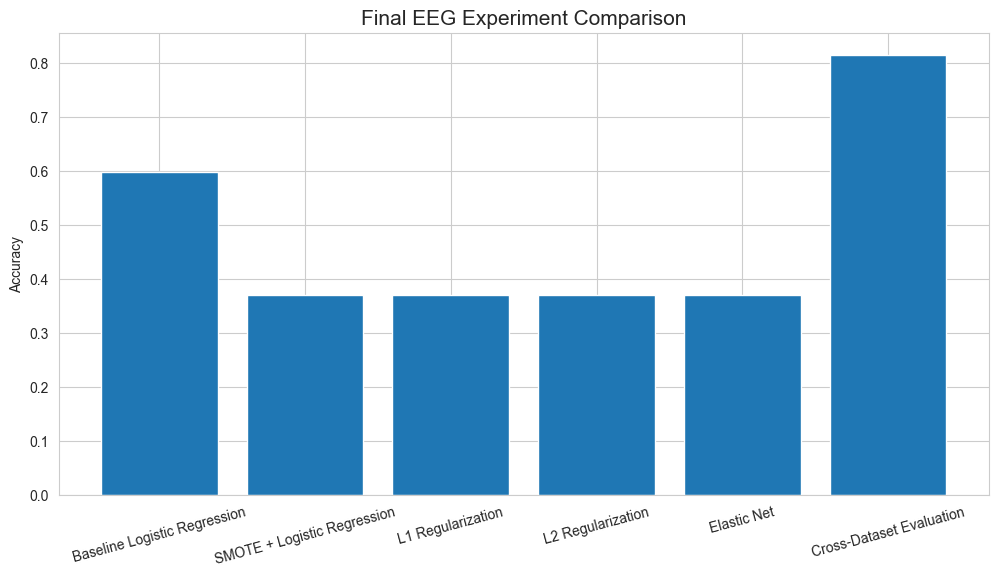

In [101]:
# ============================================================
# Step 30 — Final Comparative Visualization
# Purpose:
# Compare all EEG experiments visually
# ============================================================

# Create figure
plt.figure(figsize=(12, 6))

# Create bar chart
plt.bar(

    final_results["Experiment"],
    final_results["Accuracy"]
)

# Formatting
plt.title(
    "Final EEG Experiment Comparison",
    fontsize=15
)

plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.grid(True)

plt.show()